In [8]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import joblib

In [9]:
# ===== 1. ĐỌC DỮ LIỆU =====
df = pd.read_csv("data/my_gesture_landmarks.csv")

# 63 cột landmark + 1 cột label
X = df.drop(columns=["gesture_label"]).values
y = df["gesture_label"].values

In [10]:
# ===== 2. MÃ HÓA NHÃN =====
le = LabelEncoder()
y_encoded = le.fit_transform(y)
y_cat = to_categorical(y_encoded)

In [11]:
# ===== 3. CHUẨN HÓA =====
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [12]:

# ===== 4. CHIA TẬP TRAIN/TEST =====
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_cat, test_size=0.2, random_state=42, stratify=y_cat
)

In [13]:
# ===== 5. TẠO MÔ HÌNH MLP =====
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(y_cat.shape[1], activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

c:\VIET\Computer Vision\HandSign\.venv\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
# ===== 6. HUẤN LUYỆN =====
history = model.fit(X_train, y_train, epochs=80, batch_size=32,
                    validation_split=0.2, verbose=1)

Epoch 1/80
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4717 - loss: 1.6618 - val_accuracy: 0.8356 - val_loss: 0.7106
Epoch 2/80
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7883 - loss: 0.6876 - val_accuracy: 0.9330 - val_loss: 0.2750
Epoch 3/80
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8828 - loss: 0.3849 - val_accuracy: 0.9546 - val_loss: 0.1626
Epoch 4/80
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9159 - loss: 0.2715 - val_accuracy: 0.9725 - val_loss: 0.1025
Epoch 5/80
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9377 - loss: 0.2034 - val_accuracy: 0.9792 - val_loss: 0.0762
Epoch 6/80
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9529 - loss: 0.1618 - val_accuracy: 0.9799 - val_loss: 0.0679
Epoch 7/80
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9624 - loss: 0.1347 - val_accuracy: 0.9851 - val_loss: 0.0521
Epoch 8/80
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9656 - loss: 0.1189 - val_accuracy: 0.

In [15]:
# ===== 7. ĐÁNH GIÁ =====
loss, acc = model.evaluate(X_test, y_test)
print(f"🎯 Test Accuracy: {acc:.3f}")
print(f"📉 Test Loss: {loss:.4f}")

53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9976 - loss: 0.0176      
🎯 Test Accuracy: 0.998
📉 Test Loss: 0.0176


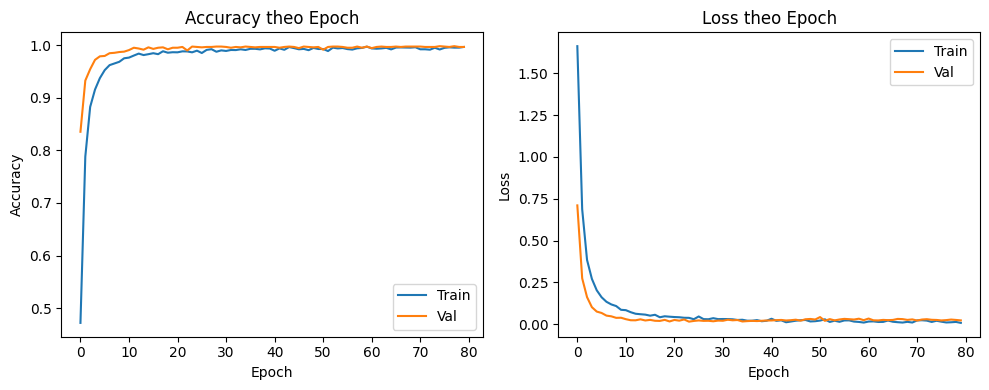

In [16]:
# ===== 8. VẼ BIỂU ĐỒ HỌC =====
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title('Accuracy theo Epoch')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title('Loss theo Epoch')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()
plt.tight_layout()
plt.show()

53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


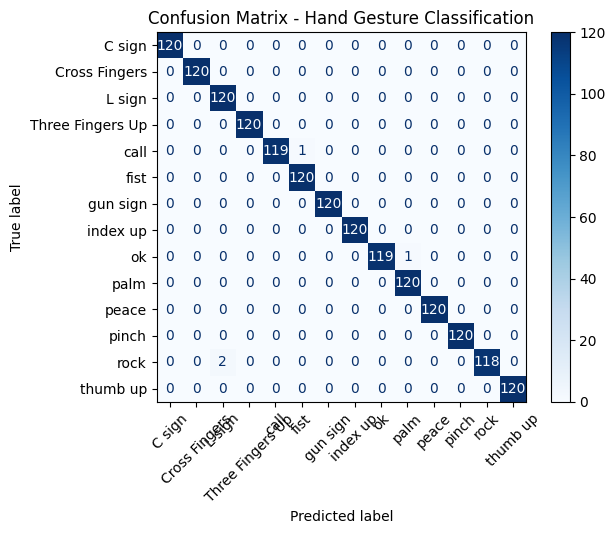

In [17]:
# ===== 9. MA TRẬN NHẦM LẪN =====
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true_classes, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix - Hand Gesture Classification")
plt.show()


In [ ]:
# ===== 10. LƯU MÔ HÌNH =====
model.save("data/hand_gesture_mlp.h5")
joblib.dump(scaler, "data/scaler.pkl")
joblib.dump(le, "data/label_encoder.pkl")

print("✅ Đã lưu mô hình, scaler và encoder.")

✅ Đã lưu mô hình, scaler và encoder.


In [19]:
# ===== 11. MAPPING LABEL → MÔ TẢ =====
gesture_info = {
  "palm": "Bàn tay mở, các ngón duỗi thẳng và tách ra",
  "fist": "Nắm tay lại, tất cả ngón gập vào lòng bàn tay",
  "thumb up": "Ngón cái giơ lên, các ngón khác gập lại",
  "peace": "Ngón trỏ và giữa giơ tạo hình chữ V",
  "ok": "Ngón cái và trỏ tạo vòng tròn, các ngón khác duỗi",
  "index up": "Chỉ giơ ngón trỏ, các ngón khác gập lại",
  "pinch": "Ngón cái và trỏ kẹp sát như hành động bóp",
  "rock": "Giơ ngón trỏ và út, các ngón khác gập lại",
  "call": "Giơ ngón cái và út ra ngoài, như ký hiệu gọi điện",
  "gun sign": "Ngón cái và trỏ tạo hình khẩu súng",
  "L sign": "Ngón cái và trỏ tạo hình chữ L",
  "C sign": "Các ngón cong lại tạo hình chữ C",
  "cross fingers": "Ngón trỏ và giữa bắt chéo nhau",
  "three fingers up": "Ba ngón tay giơ thẳng lên"
}

# ===== 12. XUẤT KẾT QUẢ DỰ ĐOÁN RA CSV =====
pred_labels = le.inverse_transform(y_pred_classes)
result_df = pd.DataFrame({
    "True_Label": le.inverse_transform(y_true_classes),
    "Predicted_Label": pred_labels,
    "Meaning": [gesture_info.get(lbl, "Unknown") for lbl in pred_labels]
})

result_df.to_csv("gesture_predictions.csv", index=False, encoding="utf-8-sig")
print("📂 Đã lưu file gesture_predictions.csv (chứa nhãn và mô tả).")

📂 Đã lưu file gesture_predictions.csv (chứa nhãn và mô tả).
